# HAI + HAIEnd — Data Analysis

| Section | What it covers |
|---------|----------------|
| **1. HAI alone** | Subsystems, column types, what actually varies |
| **2. HAIEnd alone** | Control signals, PLC outputs, what actually varies |
| **3. The 1-second offset** | Cause → effect relationship between the two datasets |
| **4. File timeline** | Chronological order, gaps — data is NOT continuous |
| **5. Merge** | Combine HAI + HAIEnd, handle duplicates |
| **6. Column audit** | Variable vs constant after merge — real feature count |
| **7. EDA** | Distributions, correlations, attack timeline |

In [1]:
import os
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

HAI_DIR   = 'C:/Users/farah/OneDrive/Desktop/AI_project/hai-23.05'
HIEND_DIR = 'C:/Users/farah/OneDrive/Desktop/AI_project/haiend-23.05'

META_COLS = {'timestamp', 'attack', 'label', 'attack_p1', 'attack_p2', 'attack_p3'}

def classify_sensor(series):
    n_unique = series.nunique()
    if n_unique <= 2:  return 'binary'
    if n_unique <= 20: return 'stepped'
    return 'continuous'

---
## Section 1 — HAI Dataset Alone

| Prefix | Subsystem | Description |
|--------|-----------|-------------|
| `P1_` | Water treatment | Flow, pressure, temperature, level |
| `P2_` | Boiler / turbine | Thermal process signals |
| `P3_` | Auxiliary | Limit and alarm signals |
| `P4_` | Gate valve | Valve position and control |
| `x1001/2/3_` | Setpoint outputs | Computed setpoint values from controllers |

All 4 train files combined for column analysis. Train1 only for time series.

In [2]:
hai_parts = []
for i in range(1, 5):
    df = pd.read_csv(os.path.join(HAI_DIR, f'hai-train{i}.csv'))
    df.rename(columns={df.columns[0]: 'timestamp'}, inplace=True)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['_file'] = f'train{i}'
    hai_parts.append(df)
    print(f"  train{i}: {len(df):>7,} rows  |  {df.timestamp.iloc[0]}  ->  {df.timestamp.iloc[-1]}")

hai_all = pd.concat(hai_parts, ignore_index=True)
sensor_cols_hai = [c for c in hai_all.columns if c not in META_COLS and c != '_file']
print(f"\nCombined: {len(hai_all):,} rows  |  {len(sensor_cols_hai)} sensor columns")

prefix_map = {
    'P1_': 'P1 — Water treatment',
    'P2_': 'P2 — Boiler/turbine',
    'P3_': 'P3 — Auxiliary',
    'P4_': 'P4 — Gate valve',
    'x'  : 'x1001/2/3 — Setpoints',
}
counts = Counter()
for col in sensor_cols_hai:
    for pfx, label in prefix_map.items():
        if col.startswith(pfx):
            counts[label] += 1
            break
print()
for label, n in sorted(counts.items()):
    print(f"  {label:<35s} {n:>3}")

  train1: 280,800 rows  |  2022-08-04 18:00:01  ->  2022-08-08 00:00:00
  train2: 291,600 rows  |  2022-08-13 07:00:01  ->  2022-08-16 16:00:00
  train3: 126,000 rows  |  2022-08-19 16:00:01  ->  2022-08-21 03:00:00
  train4: 198,000 rows  |  2022-08-22 17:00:01  ->  2022-08-25 00:00:00

Combined: 896,400 rows  |  86 sensor columns

  P1 — Water treatment                 37
  P2 — Boiler/turbine                  24
  P3 — Auxiliary                        7
  P4 — Gate valve                      11
  x1001/2/3 — Setpoints                 7


In [3]:
arr_hai  = hai_all[sensor_cols_hai].values.astype(float)
stds_hai = arr_hai.std(axis=0)

const_hai    = [col for col, s in zip(sensor_cols_hai, stds_hai) if s < 1e-6]
variable_hai = [col for col, s in zip(sensor_cols_hai, stds_hai) if s >= 1e-6]

print(f"Total HAI sensor columns:  {len(sensor_cols_hai)}")
print(f"  Constant  (std < 1e-6):  {len(const_hai)}")
print(f"  Variable  (std >= 1e-6): {len(variable_hai)}")
print()
print("Constant columns:")
for c in const_hai:
    print(f"  {c:<30s}  fixed = {hai_all[c].iloc[0]}")

Total HAI sensor columns:  86
  Constant  (std < 1e-6):  20
  Variable  (std >= 1e-6): 66

Constant columns:
  P1_PIT01_HH                     fixed = 524320
  P1_PP01AD                       fixed = 0
  P1_PP01AR                       fixed = 0
  P1_PP01BD                       fixed = 1
  P1_PP01BR                       fixed = 1
  P1_PP02D                        fixed = 1
  P1_PP02R                        fixed = 1
  P1_SOL01D                       fixed = 524320
  P1_SOL03D                       fixed = 524320
  P1_STSP                         fixed = 1
  P2_Emerg                        fixed = 0
  P2_OnOff                        fixed = 1
  P2_RTR                          fixed = 2880
  P2_TripEx                       fixed = 1
  P2_VTR01                        fixed = 50
  P2_VTR02                        fixed = 50
  P2_VTR03                        fixed = 50
  P2_VTR04                        fixed = 50
  P3_LH01                         fixed = 70
  P3_LL01                       

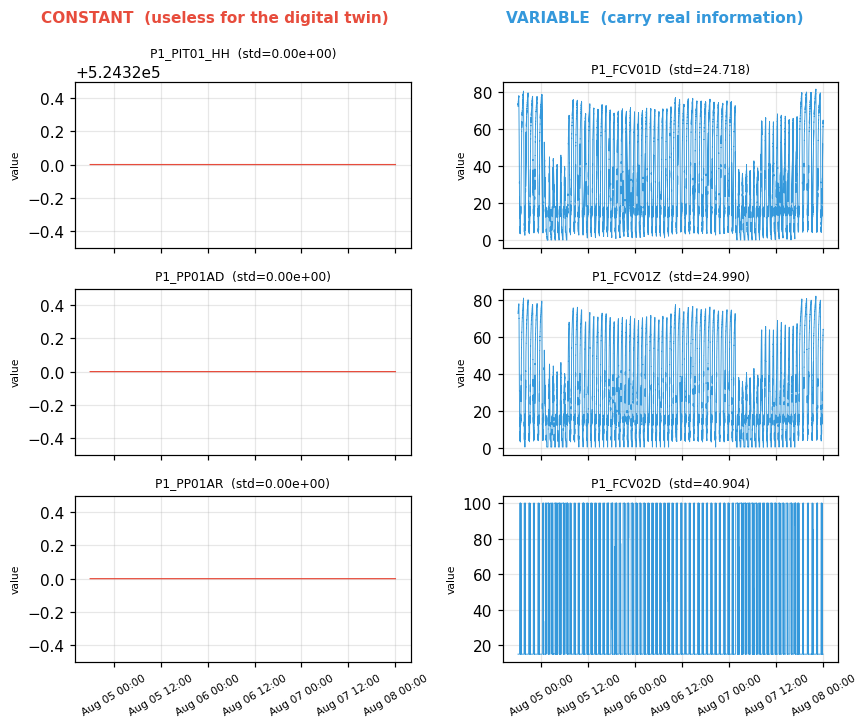

In [13]:
# --- Constant vs Variable: side-by-side visual proof ---
# Left column: constant sensors (flat lines)
# Right column: variable sensors (real signals)
# Using train1 so it's a single continuous time window

hai_t1     = hai_parts[0]
n_show     = 3  # Exactly 3 rows × 2 columns = 6 plots
show_const = const_hai[:n_show]
show_var   = variable_hai[:n_show]

fig, axes = plt.subplots(3, 2, figsize=(8, 6.6), sharex=True)

for row in range(3):
    # left: constant
    ax_c = axes[row, 0]
    col_c = show_const[row]
    ax_c.plot(hai_t1['timestamp'], hai_t1[col_c], color='#e74c3c', linewidth=0.8)
    ax_c.set_title(f'{col_c}  (std={stds_hai[sensor_cols_hai.index(col_c)]:.2e})', fontsize=8)
    ax_c.set_ylabel('value', fontsize=7)
    ax_c.grid(alpha=0.3)
    # fix y-axis so flat line is visible, not hidden at edge
    val = hai_t1[col_c].iloc[0]
    ax_c.set_ylim(val - 0.5, val + 0.5)

    # right: variable
    ax_v = axes[row, 1]
    col_v = show_var[row]
    ax_v.plot(hai_t1['timestamp'], hai_t1[col_v], color='#3498db', linewidth=0.6)
    ax_v.set_title(f'{col_v}  (std={stds_hai[sensor_cols_hai.index(col_v)]:.3f})', fontsize=8)
    ax_v.set_ylabel('value', fontsize=7)
    ax_v.grid(alpha=0.3)

for col_ax in [axes[-1, 0], axes[-1, 1]]:
    col_ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d %H:%M'))
    plt.setp(col_ax.xaxis.get_majorticklabels(), rotation=30, fontsize=7)

fig.text(0.25, 0.98, 'CONSTANT  (useless for the digital twin)',
         ha='center', color='#e74c3c', fontsize=10, fontweight='bold')
fig.text(0.75, 0.98, 'VARIABLE  (carry real information)',
         ha='center', color='#3498db', fontsize=10, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

Sensor types across variable HAI columns:
  binary         6   e.g. ['P1_PP04D', 'P2_ATSW_Lamp', 'P2_AutoGO']
  stepped        1   e.g. ['P2_ManualSD']
  continuous    59   e.g. ['P1_FCV01D', 'P1_FCV01Z', 'P1_FCV02D']

Breakdown per subsystem:
type       binary  continuous  stepped
subsystem                             
P1              1          26        0
P2              5          10        1
P3              0           5        0
P4              0          11        0
x1001/2/3       0           7        0


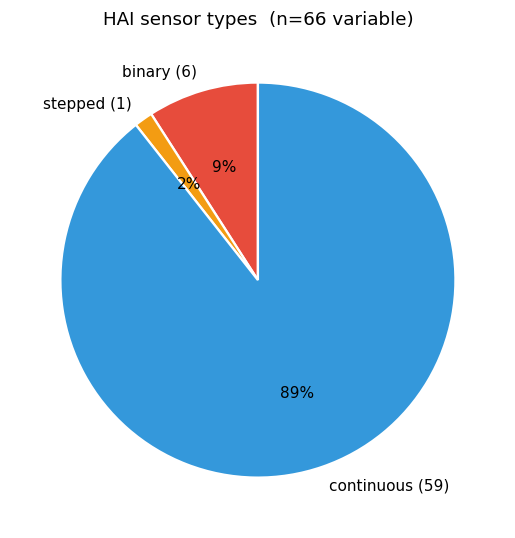

In [5]:
types_hai   = {col: classify_sensor(hai_all[col]) for col in variable_hai}
type_counts = Counter(types_hai.values())

print("Sensor types across variable HAI columns:")
for t in ['binary', 'stepped', 'continuous']:
    cols = [c for c, v in types_hai.items() if v == t]
    print(f"  {t:<12s} {type_counts[t]:>3}   e.g. {cols[:3]}")

print("\nBreakdown per subsystem:")
rows = []
for col, typ in types_hai.items():
    for pfx, label in prefix_map.items():
        if col.startswith(pfx):
            rows.append({'subsystem': label.split('—')[0].strip(), 'type': typ})
            break
breakdown = pd.DataFrame(rows).groupby(['subsystem','type']).size().unstack(fill_value=0)
print(breakdown)

colors = {'binary': '#e74c3c', 'stepped': '#f39c12', 'continuous': '#3498db'}
fig, ax = plt.subplots(figsize=(5, 5))
labels = [f"{t} ({type_counts[t]})" for t in ['binary','stepped','continuous']]
sizes  = [type_counts[t] for t in ['binary','stepped','continuous']]
clrs   = [colors[t]      for t in ['binary','stepped','continuous']]
ax.pie(sizes, labels=labels, colors=clrs, autopct='%1.0f%%', startangle=90,
       wedgeprops={'edgecolor':'white','linewidth':1.5})
ax.set_title(f'HAI sensor types  (n={len(variable_hai)} variable)')
plt.tight_layout()
plt.show()

---
## Section 2 — HAIEnd Dataset Alone

HAIEnd records the **control layer** — what the PLC commands the system to do.

| Prefix | Type | Description |
|--------|------|-------------|
| `DM-` | Data Module signals | Direct counterparts to HAI P1 sensors (valves, flow, pressure) |
| `1001.x-OUT` … `1020.x-OUT` | PLC function block outputs | Controller outputs — most are inactive |
| `GATEOPEN`, `PP04` | Discrete control | Gate open command, pump control |

Key expectation: most of the 225 columns will be constant (inactive PLC blocks).

In [7]:
end_parts = []
for i in range(1, 5):
    df = pd.read_csv(os.path.join(HIEND_DIR, f'end-train{i}.csv'))
    df.rename(columns={df.columns[0]: 'timestamp'}, inplace=True)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['_file'] = f'train{i}'
    end_parts.append(df)
    print(f"  train{i}: {len(df):>7,} rows  |  {df.timestamp.iloc[0]}  ->  {df.timestamp.iloc[-1]}")

end_all = pd.concat(end_parts, ignore_index=True)
sensor_cols_end = [c for c in end_all.columns if c not in META_COLS and c != '_file']
print(f"\nCombined: {len(end_all):,} rows  |  {len(sensor_cols_end)} sensor columns")

prefix_map_end = {
    'DM-'   : 'DM — Data Module',
    '1001.' : '1001.x — PLC block',
    '1002.' : '1002.x — PLC block',
    '1003.' : '1003.x — PLC block',
    '1004.' : '1004.x — PLC block',
    '1010.' : '1010.x — PLC block',
    '1011.' : '1011.x — PLC block',
    '1020.' : '1020.x — PLC block',
}
counts_end = Counter()
for col in sensor_cols_end:
    for pfx, label in prefix_map_end.items():
        if col.startswith(pfx):
            counts_end[label] += 1
            break
    else:
        counts_end['Other'] += 1

print()
for label, n in sorted(counts_end.items(), key=lambda x: -x[1]):
    print(f"  {label:<35s} {n:>3}")

  train1: 280,800 rows  |  2022-08-04 18:00:00  ->  2022-08-07 23:59:59
  train2: 291,600 rows  |  2022-08-13 07:00:00  ->  2022-08-16 15:59:59
  train3: 126,000 rows  |  2022-08-19 16:00:00  ->  2022-08-21 02:59:59
  train4: 198,000 rows  |  2022-08-22 17:00:00  ->  2022-08-24 23:59:59

Combined: 896,400 rows  |  225 sensor columns

  DM — Data Module                     71
  1010.x — PLC block                   32
  1011.x — PLC block                   32
  1004.x — PLC block                   25
  1002.x — PLC block                   19
  1003.x — PLC block                   16
  1020.x — PLC block                   14
  1001.x — PLC block                   12
  Other                                 4


In [8]:
arr_end  = end_all[sensor_cols_end].values.astype(float)
stds_end = arr_end.std(axis=0)

const_end    = [col for col, s in zip(sensor_cols_end, stds_end) if s < 1e-6]
variable_end = [col for col, s in zip(sensor_cols_end, stds_end) if s >= 1e-6]

print(f"Total HAIEnd sensor columns: {len(sensor_cols_end)}")
print(f"  Constant  (std < 1e-6):    {len(const_end)}  — inactive PLC blocks")
print(f"  Variable  (std >= 1e-6):   {len(variable_end)}  — useful features")
print()

const_groups = Counter()
for col in const_end:
    for pfx in prefix_map_end:
        if col.startswith(pfx):
            const_groups[pfx] += 1
            break
    else:
        const_groups['Other'] += 1

print("Constant columns by group:")
for pfx, n in sorted(const_groups.items(), key=lambda x: -x[1]):
    print(f"  {pfx:<15s} {n:>3} constant")
print()
print("Variable HAIEnd columns:")
for col in variable_end:
    print(f"  {col}")

Total HAIEnd sensor columns: 225
  Constant  (std < 1e-6):    158  — inactive PLC blocks
  Variable  (std >= 1e-6):   67  — useful features

Constant columns by group:
  DM-              39 constant
  1010.            32 constant
  1011.            32 constant
  1004.            23 constant
  1002.            12 constant
  1020.             8 constant
  1001.             5 constant
  1003.             5 constant
  Other             2 constant

Variable HAIEnd columns:
  DM-FT01Z
  DM-FT02Z
  DM-FT03Z
  1004.21-OUT
  1004.24-OUT
  1020.18-OUT
  1020.20-OUT
  1020.21-OUT
  DM-PP04-D
  1001.5-OUT
  1001.13-OUT
  1001.14-OUT
  1001.15-OUT
  1001.16-OUT
  1001.17-OUT
  1001.20-OUT
  1002.7-OUT
  1002.8-OUT
  1002.9-OUT
  1002.20-OUT
  1002.21-OUT
  1002.30-OUT
  1002.31-OUT
  1003.5-OUT
  1003.10-OUT
  1003.11-OUT
  1003.17-OUT
  1003.18-OUT
  1003.23-OUT
  1003.24-OUT
  1003.25-OUT
  1003.26-OUT
  1003.29-OUT
  1003.30-OUT
  1020.13-OUT
  1020.14-OUT
  1020.15-OUT
  DM-AIT-DO
  DM-AIT-PH
 

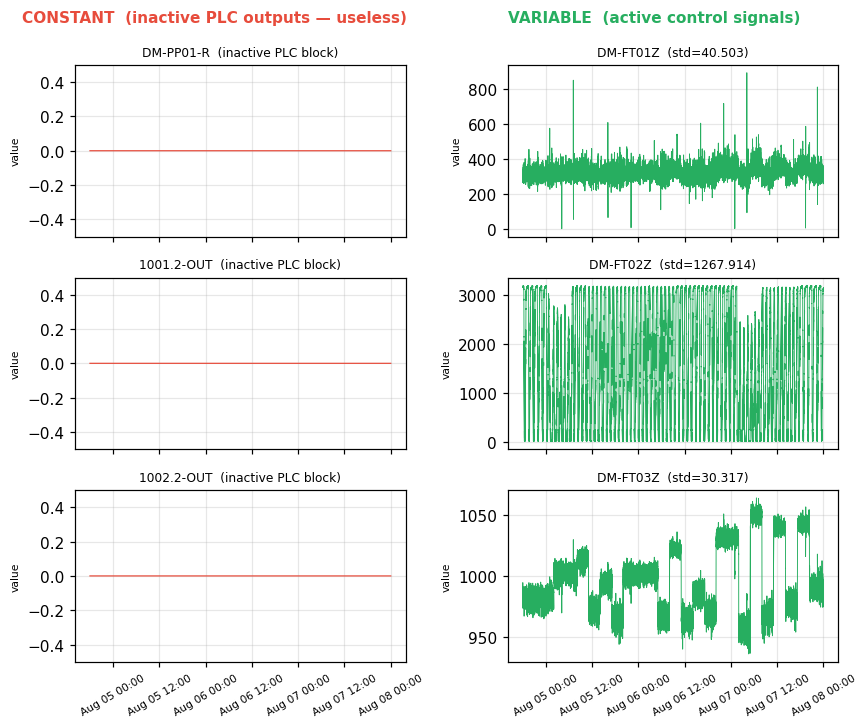

In [14]:
# --- Constant vs Variable: side-by-side visual proof for HAIEnd ---
end_t1  = end_parts[0]

# pick a spread of constant columns from different PLC block groups
groups_seen = set()
show_const_end = []
for col in const_end:
    grp = next((pfx for pfx in prefix_map_end if col.startswith(pfx)), 'Other')
    if grp not in groups_seen:
        show_const_end.append(col)
        groups_seen.add(grp)
    if len(show_const_end) == 3:  # Only 3 constant signals (left column)
        break

show_var_end = variable_end[:3]  # Only 3 variable signals (right column)

fig, axes = plt.subplots(3, 2, figsize=(8, 6.6), sharex=True)  # 3 rows × 2 columns

for row in range(3):
    # left: constant
    ax_c  = axes[row, 0]
    col_c = show_const_end[row]
    ax_c.plot(end_t1['timestamp'], end_t1[col_c], color='#e74c3c', linewidth=0.8)
    ax_c.set_title(f'{col_c}  (inactive PLC block)', fontsize=8)
    ax_c.set_ylabel('value', fontsize=7)
    ax_c.grid(alpha=0.3)
    val = end_t1[col_c].iloc[0]
    ax_c.set_ylim(val - 0.5, val + 0.5)

    # right: variable
    ax_v  = axes[row, 1]
    col_v = show_var_end[row]
    ax_v.plot(end_t1['timestamp'], end_t1[col_v], color='#27ae60', linewidth=0.6)
    ax_v.set_title(f'{col_v}  (std={stds_end[sensor_cols_end.index(col_v)]:.3f})', fontsize=8)
    ax_v.set_ylabel('value', fontsize=7)
    ax_v.grid(alpha=0.3)

for col_ax in [axes[-1, 0], axes[-1, 1]]:
    col_ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d %H:%M'))
    plt.setp(col_ax.xaxis.get_majorticklabels(), rotation=30, fontsize=7)

fig.text(0.25, 0.98, 'CONSTANT  (inactive PLC outputs — useless)',
         ha='center', color='#e74c3c', fontsize=10, fontweight='bold')
fig.text(0.75, 0.98, 'VARIABLE  (active control signals)',
         ha='center', color='#27ae60', fontsize=10, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

Sensor types across variable HAIEnd columns:
  binary         7   ['1004.21-OUT', '1004.24-OUT', '1020.18-OUT', '1020.20-OUT', '1020.21-OUT']
  stepped        1   ['DM-AIT-DO']
  continuous    59   ['DM-FT01Z', 'DM-FT02Z', 'DM-FT03Z', '1001.5-OUT', '1001.13-OUT']


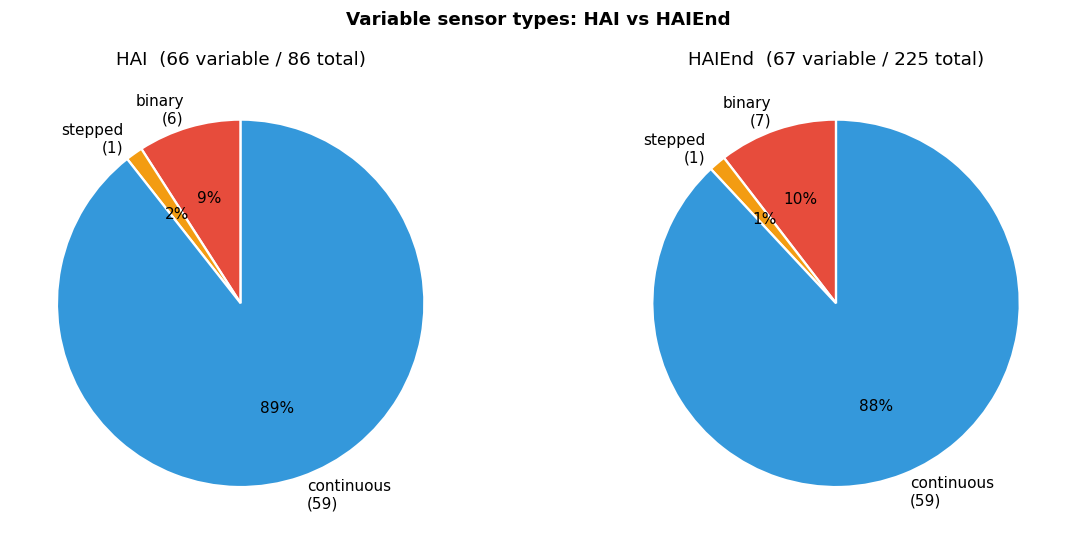

In [10]:
types_end       = {col: classify_sensor(end_all[col]) for col in variable_end}
type_counts_end = Counter(types_end.values())

print("Sensor types across variable HAIEnd columns:")
for t in ['binary', 'stepped', 'continuous']:
    cols = [c for c, v in types_end.items() if v == t]
    print(f"  {t:<12s} {type_counts_end.get(t,0):>3}   {cols[:5]}")

colors = {'binary': '#e74c3c', 'stepped': '#f39c12', 'continuous': '#3498db'}
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, (title, tc) in zip(axes, [
    (f'HAI  ({len(variable_hai)} variable / {len(sensor_cols_hai)} total)', type_counts),
    (f'HAIEnd  ({len(variable_end)} variable / {len(sensor_cols_end)} total)', type_counts_end),
]):
    sizes  = [tc.get(t, 0) for t in ['binary','stepped','continuous']]
    labels = [f"{t}\n({tc.get(t,0)})" for t in ['binary','stepped','continuous']]
    clrs   = [colors[t] for t in ['binary','stepped','continuous']]
    ax.pie(sizes, labels=labels, colors=clrs, autopct='%1.0f%%', startangle=90,
           wedgeprops={'edgecolor':'white','linewidth':1.5})
    ax.set_title(title)

fig.suptitle('Variable sensor types: HAI vs HAIEnd', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 3 — Are "constant" columns really constant? Check test data too

Some columns were constant across all 4 train files. But train data is normal operation only.  
Test files contain **attack periods** — do any of those "constant" columns suddenly change?

- Still constant in test → truly useless, safe to ignore  
- Varies in test → was dormant during normal operation, activates under attack/abnormal conditions → **interesting**

In [ ]:
# Load HAI + HAIEnd test files
hai_test_parts, end_test_parts = [], []
for i in range(1, 3):
    df = pd.read_csv(os.path.join(HAI_DIR, f'hai-test{i}.csv'))
    df.rename(columns={df.columns[0]: 'timestamp'}, inplace=True)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['_file'] = f'test{i}'
    hai_test_parts.append(df)

    df = pd.read_csv(os.path.join(HIEND_DIR, f'end-test{i}.csv'))
    df.rename(columns={df.columns[0]: 'timestamp'}, inplace=True)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['_file'] = f'test{i}'
    end_test_parts.append(df)

hai_test = pd.concat(hai_test_parts, ignore_index=True)
end_test = pd.concat(end_test_parts, ignore_index=True)

print(f"HAI test:    {len(hai_test):,} rows  |  {hai_test.timestamp.iloc[0]}  ->  {hai_test.timestamp.iloc[-1]}")
print(f"HAIEnd test: {len(end_test):,} rows  |  {end_test.timestamp.iloc[0]}  ->  {end_test.timestamp.iloc[-1]}")
if 'attack' in hai_test.columns:
    n_atk = (hai_test['attack'] > 0).sum()
    print(f"Attack rows in HAI test: {n_atk:,} / {len(hai_test):,}  ({100*n_atk/len(hai_test):.1f}%)")

In [ ]:
# Check: are the constant-in-train columns still constant in test?
def check_const_in_test(const_cols, test_df, dataset_name):
    rows = []
    for col in const_cols:
        if col not in test_df.columns:
            continue
        std_test  = float(test_df[col].std())
        n_unique  = int(test_df[col].nunique())
        rows.append({'column': col, 'std_test': round(std_test, 6),
                     'n_unique_test': n_unique, 'still_constant': std_test < 1e-6})
    df = pd.DataFrame(rows)
    wakes_up = df[~df['still_constant']]
    print(f"{'='*55}")
    print(f"{dataset_name}")
    print(f"  Constant in train:       {len(const_cols)}")
    print(f"  Still constant in test:  {df['still_constant'].sum()}")
    print(f"  ACTIVATES in test:       {len(wakes_up)}  ← interesting!")
    if len(wakes_up):
        print()
        print(wakes_up[['column', 'std_test', 'n_unique_test']].to_string(index=False))
    return wakes_up

hai_wakes = check_const_in_test(const_hai, hai_test, 'HAI')
print()
end_wakes = check_const_in_test(const_end, end_test, 'HAIEnd')

In [ ]:
# Plot wake-up columns: flat in train (left), active in test (right) with attack shading
def plot_wakeup_cols(wakes_df, train_parts, test_parts, dataset_name, attack_col='attack'):
    cols = wakes_df['column'].tolist()
    if not cols:
        print(f"No wake-up columns in {dataset_name} — all stay constant in test.")
        return
    train_t1 = train_parts[0]
    test_all  = pd.concat(test_parts, ignore_index=True)
    n = len(cols)
    fig, axes = plt.subplots(n, 2, figsize=(16, 2.5 * n), squeeze=False)
    fig.suptitle(f'{dataset_name} — constant in train, activates in test\norange = attack period',
                 fontsize=11, fontweight='bold')
    for row, col in enumerate(cols):
        # left: train — flat
        ax_tr = axes[row, 0]
        ax_tr.plot(train_t1['timestamp'], train_t1[col], color='#3498db', linewidth=0.7)
        val = train_t1[col].iloc[0]
        ax_tr.set_ylim(val - 0.5, val + 0.5)
        ax_tr.set_title(f'{col} — TRAIN (flat)', fontsize=8)
        ax_tr.grid(alpha=0.3)
        ax_tr.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        plt.setp(ax_tr.xaxis.get_majorticklabels(), rotation=20, fontsize=7)
        # right: test — active
        ax_te = axes[row, 1]
        ax_te.plot(test_all['timestamp'], test_all[col], color='#e74c3c', linewidth=0.7)
        if attack_col in test_all.columns:
            atk  = test_all[attack_col].fillna(0).astype(float)
            ymin = test_all[col].min(); ymax = test_all[col].max()
            ax_te.fill_between(test_all['timestamp'], ymin, ymax,
                               where=atk > 0, alpha=0.2, color='orange', label='attack')
            ax_te.legend(fontsize=7)
        ax_te.set_title(f'{col} — TEST (activates!)', fontsize=8, color='#e74c3c')
        ax_te.grid(alpha=0.3)
        ax_te.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        plt.setp(ax_te.xaxis.get_majorticklabels(), rotation=20, fontsize=7)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

plot_wakeup_cols(hai_wakes, hai_parts, hai_test_parts, 'HAI')
plot_wakeup_cols(end_wakes, end_parts, end_test_parts, 'HAIEnd')

### Section 3 — Summary

| Dataset | Total columns | Always constant (drop) | Wakes up in test | Variable in train (keep) |
|---------|:---:|:---:|:---:|:---:|
| HAI | 86 | 18 | 2 | 66 |
| HAIEnd | 225 | 151 | 7 | 67 |

- **Always constant** → drop from model input entirely  
- **Wakes up in test** → flat during training (model can't learn them), but active during attacks — keep in test evaluation to observe reconstruction error  
- **Variable in train** → these are the real features for the digital twin

---
## Section 4 — Duplicate Verification: HAI vs HAIEnd

The `data_loader.py` lists 35 HAI columns that are claimed to be duplicates of HAIEnd columns.  
Before trusting this list we need to verify three things:

1. Does the HAI column actually exist?
2. Does the HAIEnd counterpart actually exist?
3. Do the values actually match (correlation ≈ 1.0 after the 1s offset)?

In [ ]:
# The claimed duplicate pairs from data_loader.py: (HAI_col, HAIEnd_col)
CLAIMED_PAIRS = [
    ('P1_B2016',    '1001.15-OUT'),   # NOTE: P1_B2016 may not exist
    ('P1_FCV01D',   'DM-FCV01-D'),
    ('P1_FCV01Z',   'DM-FCV01-Z'),
    ('P1_FCV02D',   'DM-FCV02-D'),
    ('P1_FCV02Z',   'DM-FCV02-Z'),
    ('P1_FCV03D',   'DM-FCV03-D'),
    ('P1_FCV03Z',   'DM-FCV03-Z'),
    ('P1_FT01',     'DM-FT01'),
    ('P1_FT01Z',    'DM-FT01Z'),
    ('P1_FT02',     'DM-FT02'),
    ('P1_FT02Z',    'DM-FT02Z'),
    ('P1_FT03',     'DM-FT03'),
    ('P1_FT03Z',    'DM-FT03Z'),
    ('P1_LCV01D',   'DM-LCV01-D'),
    ('P1_LCV01Z',   'DM-LCV01-Z'),
    ('P1_LIT01',    'DM-LIT01'),
    ('P1_PCV01D',   'DM-PCV01-D'),
    ('P1_PCV01Z',   'DM-PCV01-Z'),
    ('P1_PCV02D',   'DM-PCV02-D'),
    ('P1_PCV02Z',   'DM-PCV02-Z'),
    ('P1_PIT01_HH', 'DM-PIT01-HH'),
    ('P1_PIT01',    'DM-PIT01'),
    ('P1_PIT02',    'DM-PIT02'),
    ('P1_PP01AD',   'DM-PP01A-D'),
    ('P1_PP01AR',   'DM-PP01A-R'),
    ('P1_PP01BD',   'DM-PP01B-D'),
    ('P1_PP01BR',   'DM-PP01B-R'),
    ('P1_PP02D',    'DM-PP02-D'),
    ('P1_PP02R',    'DM-PP02-R'),
    ('P1_SOL01D',   'DM-SOL01-D'),
    ('P1_SOL03D',   'DM-SOL03-D'),
    ('P1_STSP',     'DM-ST-SP'),
    ('P1_TIT01',    'DM-TIT01'),
    ('P1_TIT03',    'DM-TIT02'),   # naming mismatch: HAI TIT03 = HAIEnd TIT02
    ('P4_ST_GOV',   'GATEOPEN'),
]

# Step 1 & 2 — existence check
hai1 = hai_parts[0]   # already loaded
end1 = end_parts[0]

results = []
for hai_col, end_col in CLAIMED_PAIRS:
    hai_exists = hai_col in hai1.columns
    end_exists = end_col in end1.columns
    results.append({
        'HAI_col'    : hai_col,
        'HAIEnd_col' : end_col,
        'HAI_exists' : hai_exists,
        'END_exists' : end_exists,
    })

df_check = pd.DataFrame(results)
missing_hai = df_check[~df_check['HAI_exists']]
missing_end = df_check[~df_check['END_exists']]

print(f"Total claimed pairs: {len(CLAIMED_PAIRS)}")
print(f"HAI col missing:     {len(missing_hai)}")
print(f"HAIEnd col missing:  {len(missing_end)}")
print()
if len(missing_hai):
    print("HAI columns NOT found:")
    for _, r in missing_hai.iterrows():
        print(f"  '{r.HAI_col}'  (claimed counterpart: {r.HAIEnd_col})")
if len(missing_end):
    print("HAIEnd columns NOT found:")
    for _, r in missing_end.iterrows():
        print(f"  '{r.HAIEnd_col}'  (claimed source: {r.HAI_col})")

In [ ]:
# Step 3 — correlation check for valid pairs (both columns exist)
# HAIEnd leads HAI by 1s, so shift HAIEnd back by 1 row before comparing

valid_pairs = [(h, e) for h, e in CLAIMED_PAIRS
               if h in hai1.columns and e in end1.columns]

merged_dup = pd.merge(
    hai1[['timestamp'] + [h for h, _ in valid_pairs]],
    end1[['timestamp'] + [e for _, e in valid_pairs]],
    on='timestamp', how='inner'
)

corr_results = []
for hai_col, end_col in valid_pairs:
    a = merged_dup[hai_col].values[1:]    # HAI at t
    b = merged_dup[end_col].values[:-1]   # HAIEnd at t-1 = same physical moment

    if a.std() < 1e-9 and b.std() < 1e-9:
        verdict, corr = 'both constant', 1.0
    elif a.std() < 1e-9 or b.std() < 1e-9:
        verdict, corr = 'one constant', float(np.nan)
    else:
        corr = float(np.corrcoef(a, b)[0, 1])
        verdict = 'DUPLICATE ✓' if corr > 0.99 else ('close' if corr > 0.9 else 'DIFFERENT ✗')

    corr_results.append({'HAI': hai_col, 'HAIEnd': end_col,
                         'corr': round(corr, 4) if not np.isnan(corr) else None,
                         'verdict': verdict})

df_corr = pd.DataFrame(corr_results)
print(df_corr.to_string(index=False))
print()
print(f"DUPLICATE ✓  (corr > 0.99): {(df_corr.verdict == 'DUPLICATE ✓').sum()}")
print(f"both constant:              {(df_corr.verdict == 'both constant').sum()}")
print(f"one constant:               {(df_corr.verdict == 'one constant').sum()}")
print(f"close (0.9–0.99):           {(df_corr.verdict == 'close').sum()}")
print(f"DIFFERENT ✗  (corr < 0.9):  {(df_corr.verdict == 'DIFFERENT ✗').sum()}")

In [ ]:
# Visual spot-check: overlay HAI (blue) vs HAIEnd shifted +1s (red dashed)
# Pick one from each verdict category to see what each looks like
spot = []
for verdict in ['DUPLICATE ✓', 'both constant', 'one constant', 'DIFFERENT ✗', 'close']:
    match = df_corr[df_corr.verdict == verdict]
    if len(match):
        spot.append(match.iloc[0])

fig, axes = plt.subplots(len(spot), 1, figsize=(16, 3 * len(spot)), squeeze=False)
for ax, row in zip(axes[:, 0], spot):
    t = merged_dup['timestamp']
    ax.plot(t, merged_dup[row.HAI],              color='#3498db', lw=0.8,
            label=f'HAI: {row.HAI}')
    ax.plot(t, merged_dup[row.HAIEnd].shift(1),  color='#e74c3c', lw=0.8, ls='--',
            label=f'HAIEnd: {row.HAIEnd} (+1s shifted)', alpha=0.8)
    corr_str = f"corr={row.corr}" if row.corr is not None else "corr=N/A"
    ax.set_title(f"{row.verdict}  |  {corr_str}", fontsize=9,
                 color='#27ae60' if '✓' in str(row.verdict) else
                       '#e74c3c' if '✗' in str(row.verdict) else '#2c3e50')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d %H:%M'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=20, fontsize=7)

fig.suptitle('Duplicate spot-check — HAI (blue) vs HAIEnd shifted 1s (red dashed)\n'
             'Perfect overlap = confirmed duplicate', fontsize=11, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()